# Резервная практика: SQL без Docker и MySQL

## Python + SQLite + pandas

Этот ноутбук нужен для ситуации, когда на компьютере слушателя нет Docker, MySQL или прав администратора на установку программ.

Мы изучим ту же учебную логику, что и в MySQL-сценарии:

- создадим таблицу `users`;
- добавим данные;
- выполним `SELECT`, `WHERE`, `ORDER BY`, агрегаты;
- создадим таблицу `orders`;
- разберём `FOREIGN KEY`, подзапросы, `UNION`, `INNER JOIN`, `LEFT JOIN`;
- выгрузим результаты SQL-запросов в `pandas DataFrame`.

Главная идея: **SQL-логика остаётся той же, меняется только техническая среда**.

## 1. Что такое SQLite и зачем он здесь

SQLite — это лёгкая локальная база данных. В отличие от MySQL, она не требует отдельного сервера, Docker-контейнера или установки службы базы данных.

Для занятия это удобно:

- база создаётся как обычный файл `.db`;
- SQL-запросы можно выполнять прямо из Jupyter Notebook;
- Python уже содержит модуль `sqlite3` для подключения к SQLite;
- результаты можно сразу смотреть как таблицы pandas.

Важно: **SQLite не является полной заменой MySQL в промышленной разработке**, но отлично подходит для учебной практики по базовому SQL.

## 2. Отличия MySQL и SQLite, которые нужно знать

| Тема | MySQL | SQLite |
|---|---|---|
| Запуск | Нужен сервер MySQL или Docker | Сервер не нужен |
| База данных | `CREATE DATABASE my_database;` | База — это файл `.db` |
| Выбор базы | `USE my_database;` | Не используется |
| Автонумерация | `AUTO_INCREMENT` | `INTEGER PRIMARY KEY AUTOINCREMENT` |
| Текстовый тип | `VARCHAR(50)` | `TEXT` |
| Деньги | `DECIMAL(10, 2)` | `NUMERIC` |
| Дата | `DATE` | Часто `TEXT` в формате `YYYY-MM-DD` |
| Подключение из Python | Через драйвер MySQL | Через встроенный `sqlite3` |

Для учебных запросов `SELECT`, `WHERE`, `ORDER BY`, `COUNT`, `AVG`, `SUM`, `JOIN` различия минимальны.

## 3. Импорт библиотек и создание базы

Нам понадобятся две библиотеки:

- `sqlite3` — встроенный модуль Python для работы с SQLite;
- `pandas` — библиотека для удобного просмотра результатов SQL-запросов в виде таблиц.

В этом ноутбуке база будет храниться в файле `seminar_sqlite_backup.db`.

Чтобы ноутбук можно было запускать несколько раз подряд, в начале мы удаляем старую версию базы и создаём новую.

In [1]:
from pathlib import Path
import sqlite3
import pandas as pd

DB_PATH = Path("seminar_sqlite_backup.db")

# Делаем ноутбук повторяемым: каждый запуск начинает практику с чистой базы.
if DB_PATH.exists():
    DB_PATH.unlink()

connection = sqlite3.connect(DB_PATH)

# В SQLite проверку внешних ключей нужно включать явно для каждого подключения.
connection.execute("PRAGMA foreign_keys = ON;")

print(f"База данных создана: {DB_PATH.resolve()}")

База данных создана: /seminar_sqlite_backup.db


## 4. Удобная функция для выполнения SQL-запросов

Чтобы не писать `pd.read_sql_query(...)` каждый раз полностью, создадим маленькую функцию `sql()`.

Она принимает SQL-запрос в виде текста и возвращает результат как `DataFrame`.

In [2]:
def sql(query: str) -> pd.DataFrame:
    return pd.read_sql_query(query, connection)

## 5. Создаём таблицу `users`

В MySQL мы писали бы `AUTO_INCREMENT`, а в SQLite используем:

```sql
id INTEGER PRIMARY KEY AUTOINCREMENT
```

Это означает: `id` будет главным идентификатором строки и будет увеличиваться автоматически.

In [3]:
connection.execute("""
CREATE TABLE users (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    name TEXT NOT NULL,
    email TEXT NOT NULL,
    age INTEGER NOT NULL,
    country TEXT NOT NULL,
    balance NUMERIC NOT NULL
);
""")

connection.commit()

sql("SELECT name FROM sqlite_master WHERE type = 'table';")

,name
0,users
1,sqlite_sequence


## 6. Добавляем данные в `users`

`INSERT INTO` добавляет строки в таблицу.

В SQLite из Python вместо прямой подстановки значений в строку запроса лучше использовать плейсхолдеры `?`. Это безопаснее и ближе к реальной практике работы с базами данных.

In [4]:
users = [
    ("Ivan", "ivan@example.com", 25, "RUS", 100000.00),
    ("Gleb", "gleb@example.com", 26, "RUS", 90000.00),
    ("Sergey", "sergey@example.com", 28, "RUS", 90000.00),
    ("Andrew", "andrew@example.com", 24, "RUS", 95000.00),
    ("Bob", "bob@example.com", 25, "USA", 100000.00),
    ("Tom", "tom@example.com", 29, "USA", 110000.00),
]

connection.executemany("""
INSERT INTO users (name, email, age, country, balance)
VALUES (?, ?, ?, ?, ?);
""", users)

connection.commit()

sql("SELECT * FROM users;")

,id,name,email,age,country,balance
0,1,Ivan,ivan@example.com,25,RUS,100000
1,2,Gleb,gleb@example.com,26,RUS,90000
2,3,Sergey,sergey@example.com,28,RUS,90000
3,4,Andrew,andrew@example.com,24,RUS,95000
4,5,Bob,bob@example.com,25,USA,100000
5,6,Tom,tom@example.com,29,USA,110000


## 7. Базовый `SELECT`

`SELECT` позволяет выбрать данные из таблицы.

Самый простой вариант:

```sql
SELECT * FROM users;
```

Звёздочка `*` означает: показать все столбцы.

In [5]:
sql("""
SELECT *
FROM users;
""")

,id,name,email,age,country,balance
0,1,Ivan,ivan@example.com,25,RUS,100000
1,2,Gleb,gleb@example.com,26,RUS,90000
2,3,Sergey,sergey@example.com,28,RUS,90000
3,4,Andrew,andrew@example.com,24,RUS,95000
4,5,Bob,bob@example.com,25,USA,100000
5,6,Tom,tom@example.com,29,USA,110000


## 8. Выбор отдельных столбцов

В реальной аналитике обычно не нужно забирать все столбцы. Лучше выбирать только те поля, которые нужны для задачи.

In [6]:
sql("""
SELECT id, name, age
FROM users;
""")

,id,name,age
0,1,Ivan,25
1,2,Gleb,26
2,3,Sergey,28
3,4,Andrew,24
4,5,Bob,25
5,6,Tom,29


## 9. Фильтрация через `WHERE`

`WHERE` отвечает за условие отбора строк.

Например: показать только пользователей старше 26 лет.

In [7]:
sql("""
SELECT *
FROM users
WHERE age > 26;
""")

,id,name,email,age,country,balance
0,3,Sergey,sergey@example.com,28,RUS,90000
1,6,Tom,tom@example.com,29,USA,110000


## 10. Несколько условий через `AND`

Можно объединять несколько условий.

Например: пользователи старше 26 лет и только из страны `RUS`.

In [8]:
sql("""
SELECT *
FROM users
WHERE age > 26 AND country = 'RUS';
""")

,id,name,email,age,country,balance
0,3,Sergey,sergey@example.com,28,RUS,90000


## 11. Сортировка через `ORDER BY`

`ORDER BY` сортирует результат.

- `ASC` — по возрастанию;
- `DESC` — по убыванию.

In [9]:
sql("""
SELECT *
FROM users
ORDER BY balance DESC;
""")

,id,name,email,age,country,balance
0,6,Tom,tom@example.com,29,USA,110000
1,1,Ivan,ivan@example.com,25,RUS,100000
2,5,Bob,bob@example.com,25,USA,100000
3,4,Andrew,andrew@example.com,24,RUS,95000
4,2,Gleb,gleb@example.com,26,RUS,90000
5,3,Sergey,sergey@example.com,28,RUS,90000


## 12. Диапазон значений через `BETWEEN`

`BETWEEN` выбирает значения внутри диапазона.

Например: пользователи с балансом от 95 000 до 110 000.

In [10]:
sql("""
SELECT *
FROM users
WHERE balance BETWEEN 95000 AND 110000;
""")

,id,name,email,age,country,balance
0,1,Ivan,ivan@example.com,25,RUS,100000
1,4,Andrew,andrew@example.com,24,RUS,95000
2,5,Bob,bob@example.com,25,USA,100000
3,6,Tom,tom@example.com,29,USA,110000


## 13. Агрегатные функции

Агрегатные функции считают итоговые показатели по таблице:

- `COUNT(*)` — количество строк;
- `AVG()` — среднее значение;
- `SUM()` — сумма;
- `MAX()` — максимум;
- `MIN()` — минимум.

In [11]:
sql("""
SELECT
    COUNT(*) AS users_count,
    AVG(balance) AS avg_balance,
    SUM(balance) AS total_balance,
    MAX(balance) AS max_balance,
    MIN(balance) AS min_balance
FROM users;
""")

,users_count,avg_balance,total_balance,max_balance,min_balance
0,6,97500.0,585000,110000,90000


## 14. Группировка через `GROUP BY`

`GROUP BY` собирает строки в группы и считает показатели по каждой группе.

Например: посчитаем количество пользователей и средний баланс по странам.

In [12]:
sql("""
SELECT
    country,
    COUNT(*) AS users_count,
    AVG(balance) AS avg_balance
FROM users
GROUP BY country;
""")

,country,users_count,avg_balance
0,RUS,4,93750.0
1,USA,2,105000.0


## 15. Безопасный `UPDATE`

`UPDATE` изменяет данные в таблице.

Главное правило: **сначала проверяем строки через `SELECT`, потом выполняем `UPDATE`**.

In [13]:
# Сначала проверяем, какую строку хотим изменить.
sql("""
SELECT *
FROM users
WHERE id = 2;
""")

,id,name,email,age,country,balance
0,2,Gleb,gleb@example.com,26,RUS,90000


In [14]:
# Теперь обновляем только одну строку.
connection.execute("""
UPDATE users
SET balance = 110000
WHERE id = 2;
""")

connection.commit()

sql("SELECT * FROM users WHERE id = 2;")

,id,name,email,age,country,balance
0,2,Gleb,gleb@example.com,26,RUS,110000


### Важное предупреждение

Запрос без `WHERE` изменит все строки таблицы:

```sql
UPDATE users
SET name = 'Ivan';
```

Такой запрос нельзя выполнять случайно. В учебном материале его можно показывать только как пример ошибки.

## 16. Безопасный `DELETE`

`DELETE` удаляет строки из таблицы.

Правило то же самое: **сначала `SELECT`, потом `DELETE`**.

В примере удалим пользователя `Bob`, но сначала проверим строку.

In [15]:
sql("""
SELECT *
FROM users
WHERE name = 'Bob';
""")

,id,name,email,age,country,balance
0,5,Bob,bob@example.com,25,USA,100000


In [16]:
connection.execute("""
DELETE FROM users
WHERE name = 'Bob';
""")

connection.commit()

sql("SELECT * FROM users;")

,id,name,email,age,country,balance
0,1,Ivan,ivan@example.com,25,RUS,100000
1,2,Gleb,gleb@example.com,26,RUS,110000
2,3,Sergey,sergey@example.com,28,RUS,90000
3,4,Andrew,andrew@example.com,24,RUS,95000
4,6,Tom,tom@example.com,29,USA,110000


## 17. Создаём таблицу `orders`

Теперь добавим вторую таблицу — `orders`.

Она будет хранить заказы пользователей.

Связь такая:

```text
users.id  →  orders.user_id
```

То есть `orders.user_id` показывает, какому пользователю принадлежит заказ.

In [17]:
connection.execute("""
CREATE TABLE orders (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    user_id INTEGER NOT NULL,
    product_name TEXT NOT NULL,
    price NUMERIC NOT NULL,
    quantity INTEGER NOT NULL,
    order_date TEXT NOT NULL,
    FOREIGN KEY (user_id) REFERENCES users(id)
);
""")

connection.commit()

sql("SELECT name FROM sqlite_master WHERE type = 'table';")

,name
0,users
1,sqlite_sequence
2,orders


## 18. Добавляем заказы

Добавим несколько заказов. Обратите внимание: `user_id` должен ссылаться на существующего пользователя из таблицы `users`.

In [18]:
orders = [
    (1, "Product A", 10.00, 2, "2023-02-22"),
    (2, "Product B", 20.00, 1, "2023-02-20"),
    (2, "Product C", 15.00, 3, "2023-02-23"),
    (1, "Product D", 12.00, 2, "2023-02-25"),
    (2, "Product E", 25.00, 1, "2023-02-26"),
]

connection.executemany("""
INSERT INTO orders (user_id, product_name, price, quantity, order_date)
VALUES (?, ?, ?, ?, ?);
""", orders)

connection.commit()

sql("SELECT * FROM orders;")

,id,user_id,product_name,price,quantity,order_date
0,1,1,Product A,10,2,2023-02-22
1,2,2,Product B,20,1,2023-02-20
2,3,2,Product C,15,3,2023-02-23
3,4,1,Product D,12,2,2023-02-25
4,5,2,Product E,25,1,2023-02-26


## 19. Проверяем внешний ключ

Попробуем вставить заказ для пользователя с `user_id = 999`.

Такого пользователя нет, поэтому база должна запретить вставку.

In [19]:
try:
    connection.execute("""
    INSERT INTO orders (user_id, product_name, price, quantity, order_date)
    VALUES (999, 'Wrong Product', 10.00, 1, '2023-02-27');
    """)
    connection.commit()
except sqlite3.IntegrityError as error:
    print("Ошибка внешнего ключа:", error)

Ошибка внешнего ключа: FOREIGN KEY constraint failed


## 20. Вычисляемый столбец

SQL может не только выбирать готовые столбцы, но и создавать расчётные поля.

Например, сумма заказа:

```sql
price * quantity AS order_total
```

In [20]:
sql("""
SELECT
    id,
    product_name,
    price,
    quantity,
    price * quantity AS order_total,
    order_date
FROM orders;
""")

,id,product_name,price,quantity,order_total,order_date
0,1,Product A,10,2,20,2023-02-22
1,2,Product B,20,1,20,2023-02-20
2,3,Product C,15,3,45,2023-02-23
3,4,Product D,12,2,24,2023-02-25
4,5,Product E,25,1,25,2023-02-26


## 21. Подзапрос

Подзапрос — это запрос внутри другого запроса.

Пример: сначала найти `id` пользователя `Gleb`, потом найти его заказы.

In [21]:
sql("""
SELECT *
FROM orders
WHERE user_id = (
    SELECT id
    FROM users
    WHERE name = 'Gleb'
);
""")

,id,user_id,product_name,price,quantity,order_date
0,2,2,Product B,20,1,2023-02-20
1,3,2,Product C,15,3,2023-02-23
2,5,2,Product E,25,1,2023-02-26


## 22. `UNION` и `UNION ALL`

`UNION` объединяет результаты нескольких `SELECT`-запросов.

Важно: количество столбцов и их смысл должны совпадать.

`UNION` убирает дубли, а `UNION ALL` оставляет все строки.

In [22]:
sql("""
SELECT id, name AS title, 'user' AS source
FROM users
UNION
SELECT id, product_name AS title, 'order' AS source
FROM orders;
""")

,id,title,source
0,1,Ivan,user
1,1,Product A,order
2,2,Gleb,user
3,2,Product B,order
4,3,Product C,order
5,3,Sergey,user
6,4,Andrew,user
7,4,Product D,order
8,5,Product E,order
9,6,Tom,user


## 23. `INNER JOIN`

`INNER JOIN` показывает только те строки, где есть совпадение в обеих таблицах.

В нашем случае: только пользователей, у которых есть заказы.

In [23]:
sql("""
SELECT
    users.name,
    users.email,
    orders.product_name,
    orders.order_date
FROM users
INNER JOIN orders
ON users.id = orders.user_id;
""")

,name,email,product_name,order_date
0,Ivan,ivan@example.com,Product A,2023-02-22
1,Gleb,gleb@example.com,Product B,2023-02-20
2,Gleb,gleb@example.com,Product C,2023-02-23
3,Ivan,ivan@example.com,Product D,2023-02-25
4,Gleb,gleb@example.com,Product E,2023-02-26


## 24. `LEFT JOIN`

`LEFT JOIN` показывает все строки из левой таблицы и добавляет данные из правой таблицы, если они есть.

В нашем случае: все пользователи, даже если у них нет заказов.

In [24]:
sql("""
SELECT
    users.name,
    users.email,
    orders.product_name,
    orders.order_date
FROM users
LEFT JOIN orders
ON users.id = orders.user_id;
""")

,name,email,product_name,order_date
0,Ivan,ivan@example.com,Product A,2023-02-22
1,Ivan,ivan@example.com,Product D,2023-02-25
2,Gleb,gleb@example.com,Product B,2023-02-20
3,Gleb,gleb@example.com,Product C,2023-02-23
4,Gleb,gleb@example.com,Product E,2023-02-26
5,Sergey,sergey@example.com,None,None
6,Andrew,andrew@example.com,None,None
7,Tom,tom@example.com,None,None


## 25. Пользователи без заказов

`LEFT JOIN` часто используют, чтобы найти отсутствующие связи.

Например: кто есть в таблице `users`, но не имеет заказов в `orders`.

In [25]:
sql("""
SELECT
    users.id,
    users.name,
    users.email
FROM users
LEFT JOIN orders
ON users.id = orders.user_id
WHERE orders.id IS NULL;
""")

,id,name,email
0,3,Sergey,sergey@example.com
1,4,Andrew,andrew@example.com
2,6,Tom,tom@example.com


## 26. Аналитический запрос: выручка по пользователям

Теперь соберём отчёт: сколько заказов сделал каждый пользователь и какую сумму принёс.

In [26]:
sql("""
SELECT
    users.name,
    COUNT(orders.id) AS orders_count,
    COALESCE(SUM(orders.price * orders.quantity), 0) AS revenue
FROM users
LEFT JOIN orders
ON users.id = orders.user_id
GROUP BY users.id, users.name
ORDER BY revenue DESC;
""")

,name,orders_count,revenue
0,Gleb,3,90
1,Ivan,2,44
2,Sergey,0,0
3,Andrew,0,0
4,Tom,0,0


## 27. SQL-запрос → pandas DataFrame

Это ключевой мост к Python-аналитике.

Мы можем выполнить SQL-запрос, получить результат и дальше работать с ним как с обычным `DataFrame`.

In [27]:
sales = sql("""
SELECT
    users.id AS user_id,
    users.name,
    users.country,
    orders.product_name,
    orders.price,
    orders.quantity,
    orders.price * orders.quantity AS order_total,
    orders.order_date
FROM users
INNER JOIN orders
ON users.id = orders.user_id;
""")

sales

,user_id,name,country,product_name,price,quantity,order_total,order_date
0,1,Ivan,RUS,Product A,10,2,20,2023-02-22
1,2,Gleb,RUS,Product B,20,1,20,2023-02-20
2,2,Gleb,RUS,Product C,15,3,45,2023-02-23
3,1,Ivan,RUS,Product D,12,2,24,2023-02-25
4,2,Gleb,RUS,Product E,25,1,25,2023-02-26


## 28. Мини-анализ в pandas

После выгрузки из SQL можно использовать pandas.

Например, посчитаем общую выручку, средний чек и выручку по пользователям.

In [28]:
total_revenue = sales["order_total"].sum()
avg_order = sales["order_total"].mean()

print("Общая выручка:", total_revenue)
print("Средний заказ:", avg_order)

Общая выручка: 134
Средний заказ: 26.8


In [29]:
sales.groupby("name", as_index=False)["order_total"].sum().sort_values("order_total", ascending=False)

,name,order_total
0,Gleb,90
1,Ivan,44


## 29. Простой график

Построим график выручки по пользователям.

Text(0, 0.5, 'Выручка')

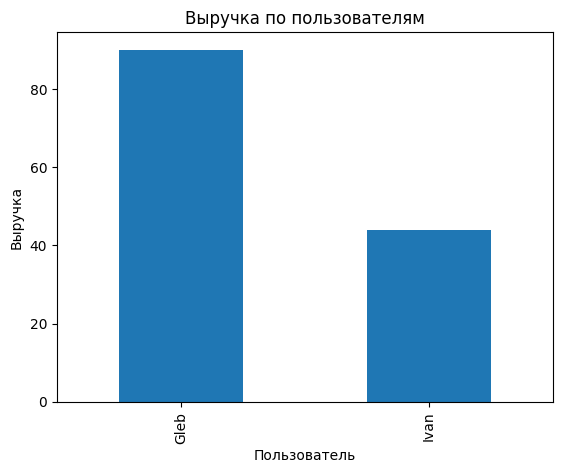

In [30]:
revenue_by_user = sales.groupby("name")["order_total"].sum().sort_values(ascending=False)

ax = revenue_by_user.plot(kind="bar", title="Выручка по пользователям")
ax.set_xlabel("Пользователь")
ax.set_ylabel("Выручка")

# Практика для слушателей

Выполните задания ниже. Почти все решения можно сделать через функцию `sql()`.

## Задание 1

Выведите всех пользователей из таблицы `users`.

In [31]:
# Ваш код здесь

## Задание 2

Выведите только столбцы `name`, `email`, `country`.

In [32]:
# Ваш код здесь

## Задание 3

Найдите пользователей из страны `RUS`.

In [33]:
# Ваш код здесь

## Задание 4

Найдите пользователей с балансом больше `100000`.

In [34]:
# Ваш код здесь

## Задание 5

Отсортируйте пользователей по балансу по убыванию.

In [35]:
# Ваш код здесь

## Задание 6

Посчитайте количество пользователей по странам.

In [36]:
# Ваш код здесь

## Задание 7

Выведите все заказы пользователя `Gleb` через подзапрос.

In [37]:
# Ваш код здесь

## Задание 8

Выведите имя пользователя, название товара и сумму заказа через `INNER JOIN`.

In [38]:
# Ваш код здесь

## Задание 9

Найдите пользователей без заказов через `LEFT JOIN`.

In [39]:
# Ваш код здесь

## Задание 10

Соберите отчёт: имя пользователя, количество заказов, общая сумма заказов.

In [40]:
# Ваш код здесь

# Решения для самопроверки

Этот блок можно удалить перед выдачей ноутбука слушателям, если нужна версия без ответов.

## Решение 1

In [41]:
sql("SELECT * FROM users;")

,id,name,email,age,country,balance
0,1,Ivan,ivan@example.com,25,RUS,100000
1,2,Gleb,gleb@example.com,26,RUS,110000
2,3,Sergey,sergey@example.com,28,RUS,90000
3,4,Andrew,andrew@example.com,24,RUS,95000
4,6,Tom,tom@example.com,29,USA,110000


## Решение 2

In [42]:
sql("SELECT name, email, country FROM users;")

,name,email,country
0,Ivan,ivan@example.com,RUS
1,Gleb,gleb@example.com,RUS
2,Sergey,sergey@example.com,RUS
3,Andrew,andrew@example.com,RUS
4,Tom,tom@example.com,USA


## Решение 3

In [43]:
sql("SELECT * FROM users WHERE country = 'RUS';")

,id,name,email,age,country,balance
0,1,Ivan,ivan@example.com,25,RUS,100000
1,2,Gleb,gleb@example.com,26,RUS,110000
2,3,Sergey,sergey@example.com,28,RUS,90000
3,4,Andrew,andrew@example.com,24,RUS,95000


## Решение 4

In [44]:
sql("SELECT * FROM users WHERE balance > 100000;")

,id,name,email,age,country,balance
0,2,Gleb,gleb@example.com,26,RUS,110000
1,6,Tom,tom@example.com,29,USA,110000


## Решение 5

In [45]:
sql("SELECT * FROM users ORDER BY balance DESC;")

,id,name,email,age,country,balance
0,2,Gleb,gleb@example.com,26,RUS,110000
1,6,Tom,tom@example.com,29,USA,110000
2,1,Ivan,ivan@example.com,25,RUS,100000
3,4,Andrew,andrew@example.com,24,RUS,95000
4,3,Sergey,sergey@example.com,28,RUS,90000


## Решение 6

In [46]:
sql("""
SELECT country, COUNT(*) AS users_count
FROM users
GROUP BY country;
""")

,country,users_count
0,RUS,4
1,USA,1


## Решение 7

In [47]:
sql("""
SELECT *
FROM orders
WHERE user_id = (
    SELECT id
    FROM users
    WHERE name = 'Gleb'
);
""")

,id,user_id,product_name,price,quantity,order_date
0,2,2,Product B,20,1,2023-02-20
1,3,2,Product C,15,3,2023-02-23
2,5,2,Product E,25,1,2023-02-26


## Решение 8

In [48]:
sql("""
SELECT
    users.name,
    orders.product_name,
    orders.price * orders.quantity AS order_total
FROM users
INNER JOIN orders
ON users.id = orders.user_id;
""")

,name,product_name,order_total
0,Ivan,Product A,20
1,Gleb,Product B,20
2,Gleb,Product C,45
3,Ivan,Product D,24
4,Gleb,Product E,25


## Решение 9

In [49]:
sql("""
SELECT
    users.id,
    users.name,
    users.email
FROM users
LEFT JOIN orders
ON users.id = orders.user_id
WHERE orders.id IS NULL;
""")

,id,name,email
0,3,Sergey,sergey@example.com
1,4,Andrew,andrew@example.com
2,6,Tom,tom@example.com


## Решение 10

In [50]:
sql("""
SELECT
    users.name,
    COUNT(orders.id) AS orders_count,
    COALESCE(SUM(orders.price * orders.quantity), 0) AS revenue
FROM users
LEFT JOIN orders
ON users.id = orders.user_id
GROUP BY users.id, users.name
ORDER BY revenue DESC;
""")

,name,orders_count,revenue
0,Gleb,3,90
1,Ivan,2,44
2,Sergey,0,0
3,Andrew,0,0
4,Tom,0,0


# Итоговая шпаргалка

| Задача | SQL-команда |
|---|---|
| Показать все строки | `SELECT * FROM table;` |
| Выбрать столбцы | `SELECT col1, col2 FROM table;` |
| Отфильтровать строки | `WHERE condition` |
| Отсортировать | `ORDER BY column DESC` |
| Посчитать строки | `COUNT(*)` |
| Посчитать сумму | `SUM(column)` |
| Посчитать среднее | `AVG(column)` |
| Сгруппировать | `GROUP BY column` |
| Соединить совпавшие строки | `INNER JOIN` |
| Оставить все строки слева | `LEFT JOIN` |
| Изменить данные | `UPDATE ... SET ... WHERE ...` |
| Удалить данные | `DELETE FROM ... WHERE ...` |

Главное правило безопасности: **для `UPDATE` и `DELETE` сначала пишем проверочный `SELECT` с тем же условием**.

# Как закрыть подключение

В конце работы с базой можно закрыть подключение.

Если вы хотите продолжить выполнять запросы ниже, эту ячейку пока не запускайте.

In [51]:
# connection.close()
# print("Подключение к SQLite закрыто")